In [2]:
from datasets import load_dataset
from tqdm.auto import tqdm

# NSMC 데이터셋 불러오기 (train, test 포함)
dataset = load_dataset("nsmc")

# 데이터셋 크기 확인
print(f"Train 데이터 개수: {len(dataset['train'])}")
print(f"Test 데이터 개수: {len(dataset['test'])}")

# Train 데이터를 90% Train, 10% Validation으로 분리
split_dataset = dataset['train'].train_test_split(test_size=0.1, seed=42)
train_dataset = split_dataset['train']
val_dataset = split_dataset['test']

print(f"Train 데이터 크기: {len(train_dataset)}")
print(f"Validation 데이터 크기: {len(val_dataset)}")

# tqdm으로 데이터 확인해보기
print("Train 데이터 샘플 확인:")
for i in tqdm(range(5)):
    print(train_dataset[i])




README.md:   0%|          | 0.00/3.74k [00:00<?, ?B/s]

nsmc.py:   0%|          | 0.00/3.18k [00:00<?, ?B/s]

The repository for nsmc contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/nsmc.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N]  y


Generating train split:   0%|          | 0/150000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train 데이터 개수: 150000
Test 데이터 개수: 50000
Train 데이터 크기: 135000
Validation 데이터 크기: 15000
Train 데이터 샘플 확인:


  0%|          | 0/5 [00:00<?, ?it/s]

{'id': '5960467', 'document': '명작은 옛날과 현재의 동일한 공감대 위에 놓인다. 그리고 더스틴 호프만의 섹시미^^', 'label': 1}
{'id': '5244343', 'document': '원작에 미원을 치다.', 'label': 0}
{'id': '8786278', 'document': '경상도로 하고싶었지만 티날까봐강원도로 하셨나? 가만있는 강원도만불쌍하게 된겨?', 'label': 0}
{'id': '5452084', 'document': '나래이션 미쳤다 KBS 나레이션은 진짜 멋졌다!! 극장나래이션은 별점이아깝다!', 'label': 0}
{'id': '10045037', 'document': '영화 자체도 좋았지만. 아오이유우 때문에 모에사 할뻔했다.', 'label': 1}


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Train 데이터 토큰 길이 측정 중...


  0%|          | 0/135000 [00:00<?, ?it/s]

Validation 데이터 토큰 길이 측정 중...


  0%|          | 0/15000 [00:00<?, ?it/s]

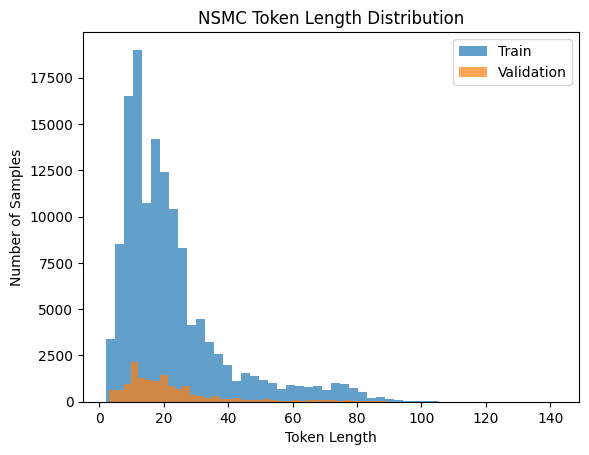

Train 최대 길이: 142, 평균 길이: 22
Validation 최대 길이: 117, 평균 길이: 22


In [3]:
from transformers import AutoTokenizer
import matplotlib.pyplot as plt

# 1. Tokenizer 불러오기 (KLUE BERT 예시, 네가 쓰고 있는 모델로 맞춰도 됨)
tokenizer = AutoTokenizer.from_pretrained("klue/bert-base")

# 2. Train 데이터셋의 문장 길이 측정
train_lengths = []

print("Train 데이터 토큰 길이 측정 중...")
for example in tqdm(train_dataset):
    tokens = tokenizer(example['document'], truncation=False, padding=False)
    length = len(tokens['input_ids'])
    train_lengths.append(length)

# 3. Validation 데이터셋도 동일하게
val_lengths = []

print("Validation 데이터 토큰 길이 측정 중...")
for example in tqdm(val_dataset):
    tokens = tokenizer(example['document'], truncation=False, padding=False)
    length = len(tokens['input_ids'])
    val_lengths.append(length)

# 4. 히스토그램 시각화
plt.hist(train_lengths, bins=50, alpha=0.7, label='Train')
plt.hist(val_lengths, bins=50, alpha=0.7, label='Validation')
plt.xlabel('Token Length')
plt.ylabel('Number of Samples')
plt.title('NSMC Token Length Distribution')
plt.legend()
plt.show()

# 최대, 평균 길이도 확인
print(f"Train 최대 길이: {max(train_lengths)}, 평균 길이: {sum(train_lengths)//len(train_lengths)}")
print(f"Validation 최대 길이: {max(val_lengths)}, 평균 길이: {sum(val_lengths)//len(val_lengths)}")


In [4]:
import numpy as np

# 95% 길이 기준 확인
train_95 = int(np.percentile(train_lengths, 95))
val_95 = int(np.percentile(val_lengths, 95))

print(f"Train 데이터 95% 길이 이하: {train_95} tokens")
print(f"Validation 데이터 95% 길이 이하: {val_95} tokens")


Train 데이터 95% 길이 이하: 62 tokens
Validation 데이터 95% 길이 이하: 62 tokens
